In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import numpy as np

## Datos
#### Para este ejercicio se utilizará el dataset 'Olivetti Faces' importado desde scikit learn. Este dataset contiene 400 imagenes de 40 personas diferentes (10 fotos por cada persona). 

#### Al separar la información del target obtenemos nuestra matriz de datos 'X_faces' de dimensión n x d, donde cada fila representa a una imagen diferente y cada columna es un pixel de la imagen.

In [2]:
from sklearn.datasets import fetch_olivetti_faces
faces = fetch_olivetti_faces()
faces.keys()

dict_keys(['data', 'images', 'target', 'DESCR'])

In [3]:
X_faces = faces.data #nuestra matriz de datos :)
y_faces = faces.target #cada etiqueta con un número distinto corresponde a una persona del dataset

In [4]:
X_faces.shape #n = 400, d = 4096 (64x64)

(400, 4096)

In [5]:
# Ahora vamos a centrar los datos restando la imagen promedio
centered_x = X_faces - X_faces.mean(axis=0)

#Aplicamos SVD a la matriz 'centered_x':
U, S, Vt = np.linalg.svd(centered_x, full_matrices=False) #recordar que s contiene los singular values. 

## Parte a -> (Valores Singulares y Varianza explicada acumulada)

Varianza explicada — PC1: 23.8%  |  PC2: 14.0%  |  Total: 37.8%


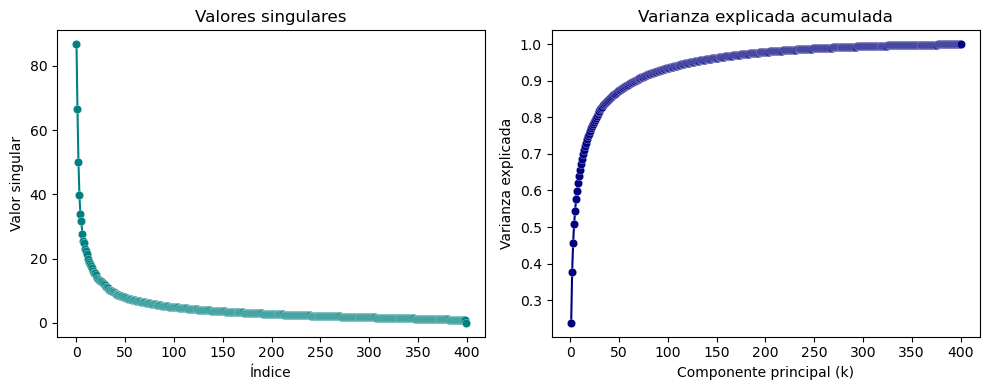

In [6]:
varianza_explicada = S**2 / np.sum(S**2)
explicada_acumulada = np.cumsum(varianza_explicada)

# Fragmento del Notebook SVD
print(f"Varianza explicada — PC1: {varianza_explicada[0]:.1%}  |  PC2: {varianza_explicada[1]:.1%}  |  Total: {varianza_explicada[:2].sum():.1%}")

# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
#Armamos los gráficos:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Valores Singulares 
sns.lineplot(data=S, marker='o', ax=axes[0], mew=0.2, color='teal')
axes[0].set(title='Valores singulares', xlabel='Índice', ylabel='Valor singular')

# Varianza Explicada Acumulada
sns.lineplot(x=list(range(1, len(explicada_acumulada) + 1)), y=explicada_acumulada, marker='o', ax=axes[1], mew=0.2, color='navy')
axes[1].set(title='Varianza explicada acumulada', xlabel='Componente principal (k)', ylabel='Varianza explicada')

plt.tight_layout()
plt.savefig('output-figures/Gráfico_parte_A.png')
plt.show()

In [7]:
perc_90 = np.argmax(explicada_acumulada >= 0.90) + 1 # El primer valor que supera el 90% de varianza explicada
perc_99 = np.argmax(explicada_acumulada >= 0.99) + 1 # El primer valor que supera el 99% de varianza explicada
perc_comp_90 = (perc_90 / len(S)) * 100
perc_comp_99 = (perc_99 / len(S)) * 100
print(f'Para explicar el 90% de la varianza, se necesitan {perc_90} ({perc_comp_90:.1f}%) componentes principales.')
print(f'Para explicar el 99% de la varianza, se necesitan {perc_99} ({perc_comp_99:.1f}%) componentes principales.')

Para explicar el 90% de la varianza, se necesitan 66 (16.5%) componentes principales.
Para explicar el 99% de la varianza, se necesitan 260 (65.0%) componentes principales.


La rapidez con la que se aplana la curva nos dice que tan 'concentrada' está la información del dataset. Por ejemplo, obtuvimos que para explicar el 90% de la varianza se necesitan solo 66 componentes (de 400), esto indica que en realidad la mayoría de la información importante está concentrada en esos 66 componentes (solo el 16.5% de los datos), mientras que desde ese punto en adelante (los +300 componentes restantes) solo aportan en un 10%.

## Parte b -> Eigen-imágenes

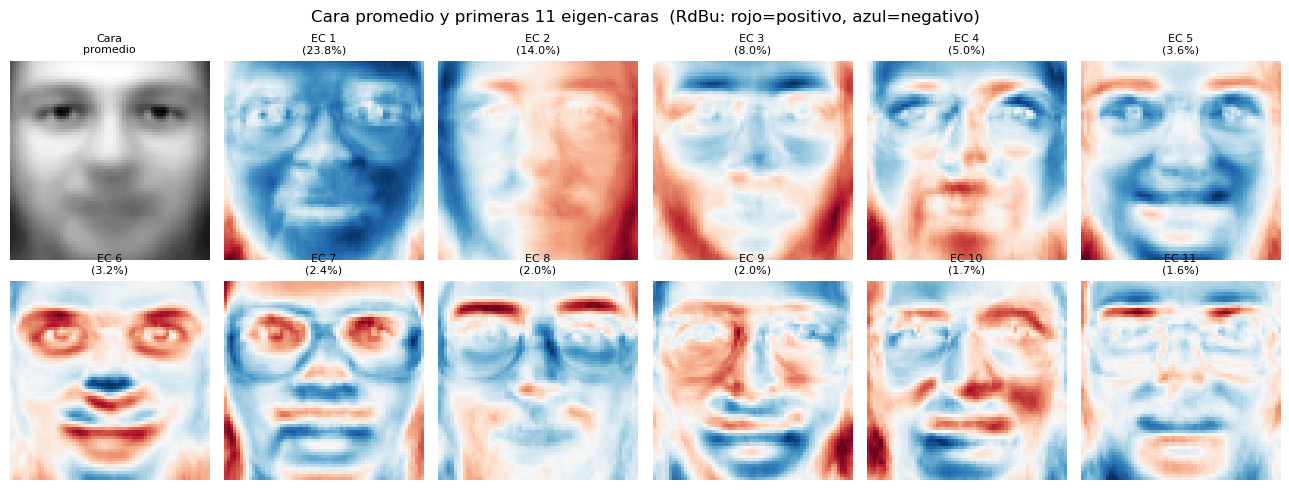

In [8]:
n = 11
fig, axes = plt.subplots(2, 6, figsize=(13, 5))

# Cara promedio
axes[0, 0].imshow(X_faces.mean(axis=0).reshape(64, 64), cmap='gray')
axes[0, 0].set_title("Cara\npromedio", fontsize=8)
axes[0, 0].axis('off')

# Eigencaras (filas de Vt)
for i, ax in enumerate(axes.flat[1:n + 1]):
    eigenface = Vt[i].reshape(64, 64)
    ax.imshow(eigenface, cmap='RdBu')
    ax.set_title(f"EC {i+1}\n({varianza_explicada[i]:.1%})", fontsize=8)
    ax.axis('off')

for ax in axes.flat[n + 1:]:
    ax.axis('off')

fig.suptitle("Cara promedio y primeras 11 eigen-caras  (RdBu: rojo=positivo, azul=negativo)")
plt.tight_layout()
plt.savefig('output-figures/Gráfico_parte_B.png')
plt.show()



EC1: Lo que estoy interpretando en la cara 1, es que al ser toda negativa (azul), neutraliza imperfecciones o detalles de la cara de las personas. Al comparar esta imagen con la cara promedio, podemos ver que esta no tiene facciones definidas, lentes o marcas en la piel. Asimismo, podría decirse que neutraliza la incidencia de la luz de las fotos (empareja el tono de piel entre las personas), ya que las zonas más oscuras (concentradas) están en las mejillas y sombras del rostro.

EC2: Aquí podemos notar que hay una división clara entre el lado derecho e izquierdo del rostro, en dónde se le da más importancia al lado derecho, y se le ‘resta’ al lado izquierdo. Dado que la partición es clara, mi interpretación es que similarmente a la imagen 1, se está capturando la incidencia de la luz, pero esta vez afectada por el ángulo desde el cuál se toma la foto. Por ejemplo, si una persona se encuentra de perfil o la luz pega más fuerte desde un lado que del otro.

EC3: En este rostro se puede ver un evidente borde rojo en los límites del rostro y que se le resta intensidad a las cejas, nariz, boca y pómulos. Mi interpretación es que esta imagen intenta capturar principalmente los bordes del rostro y la forma de la cara del sujeto.


## Parte c -> Reconstrucción progresiva

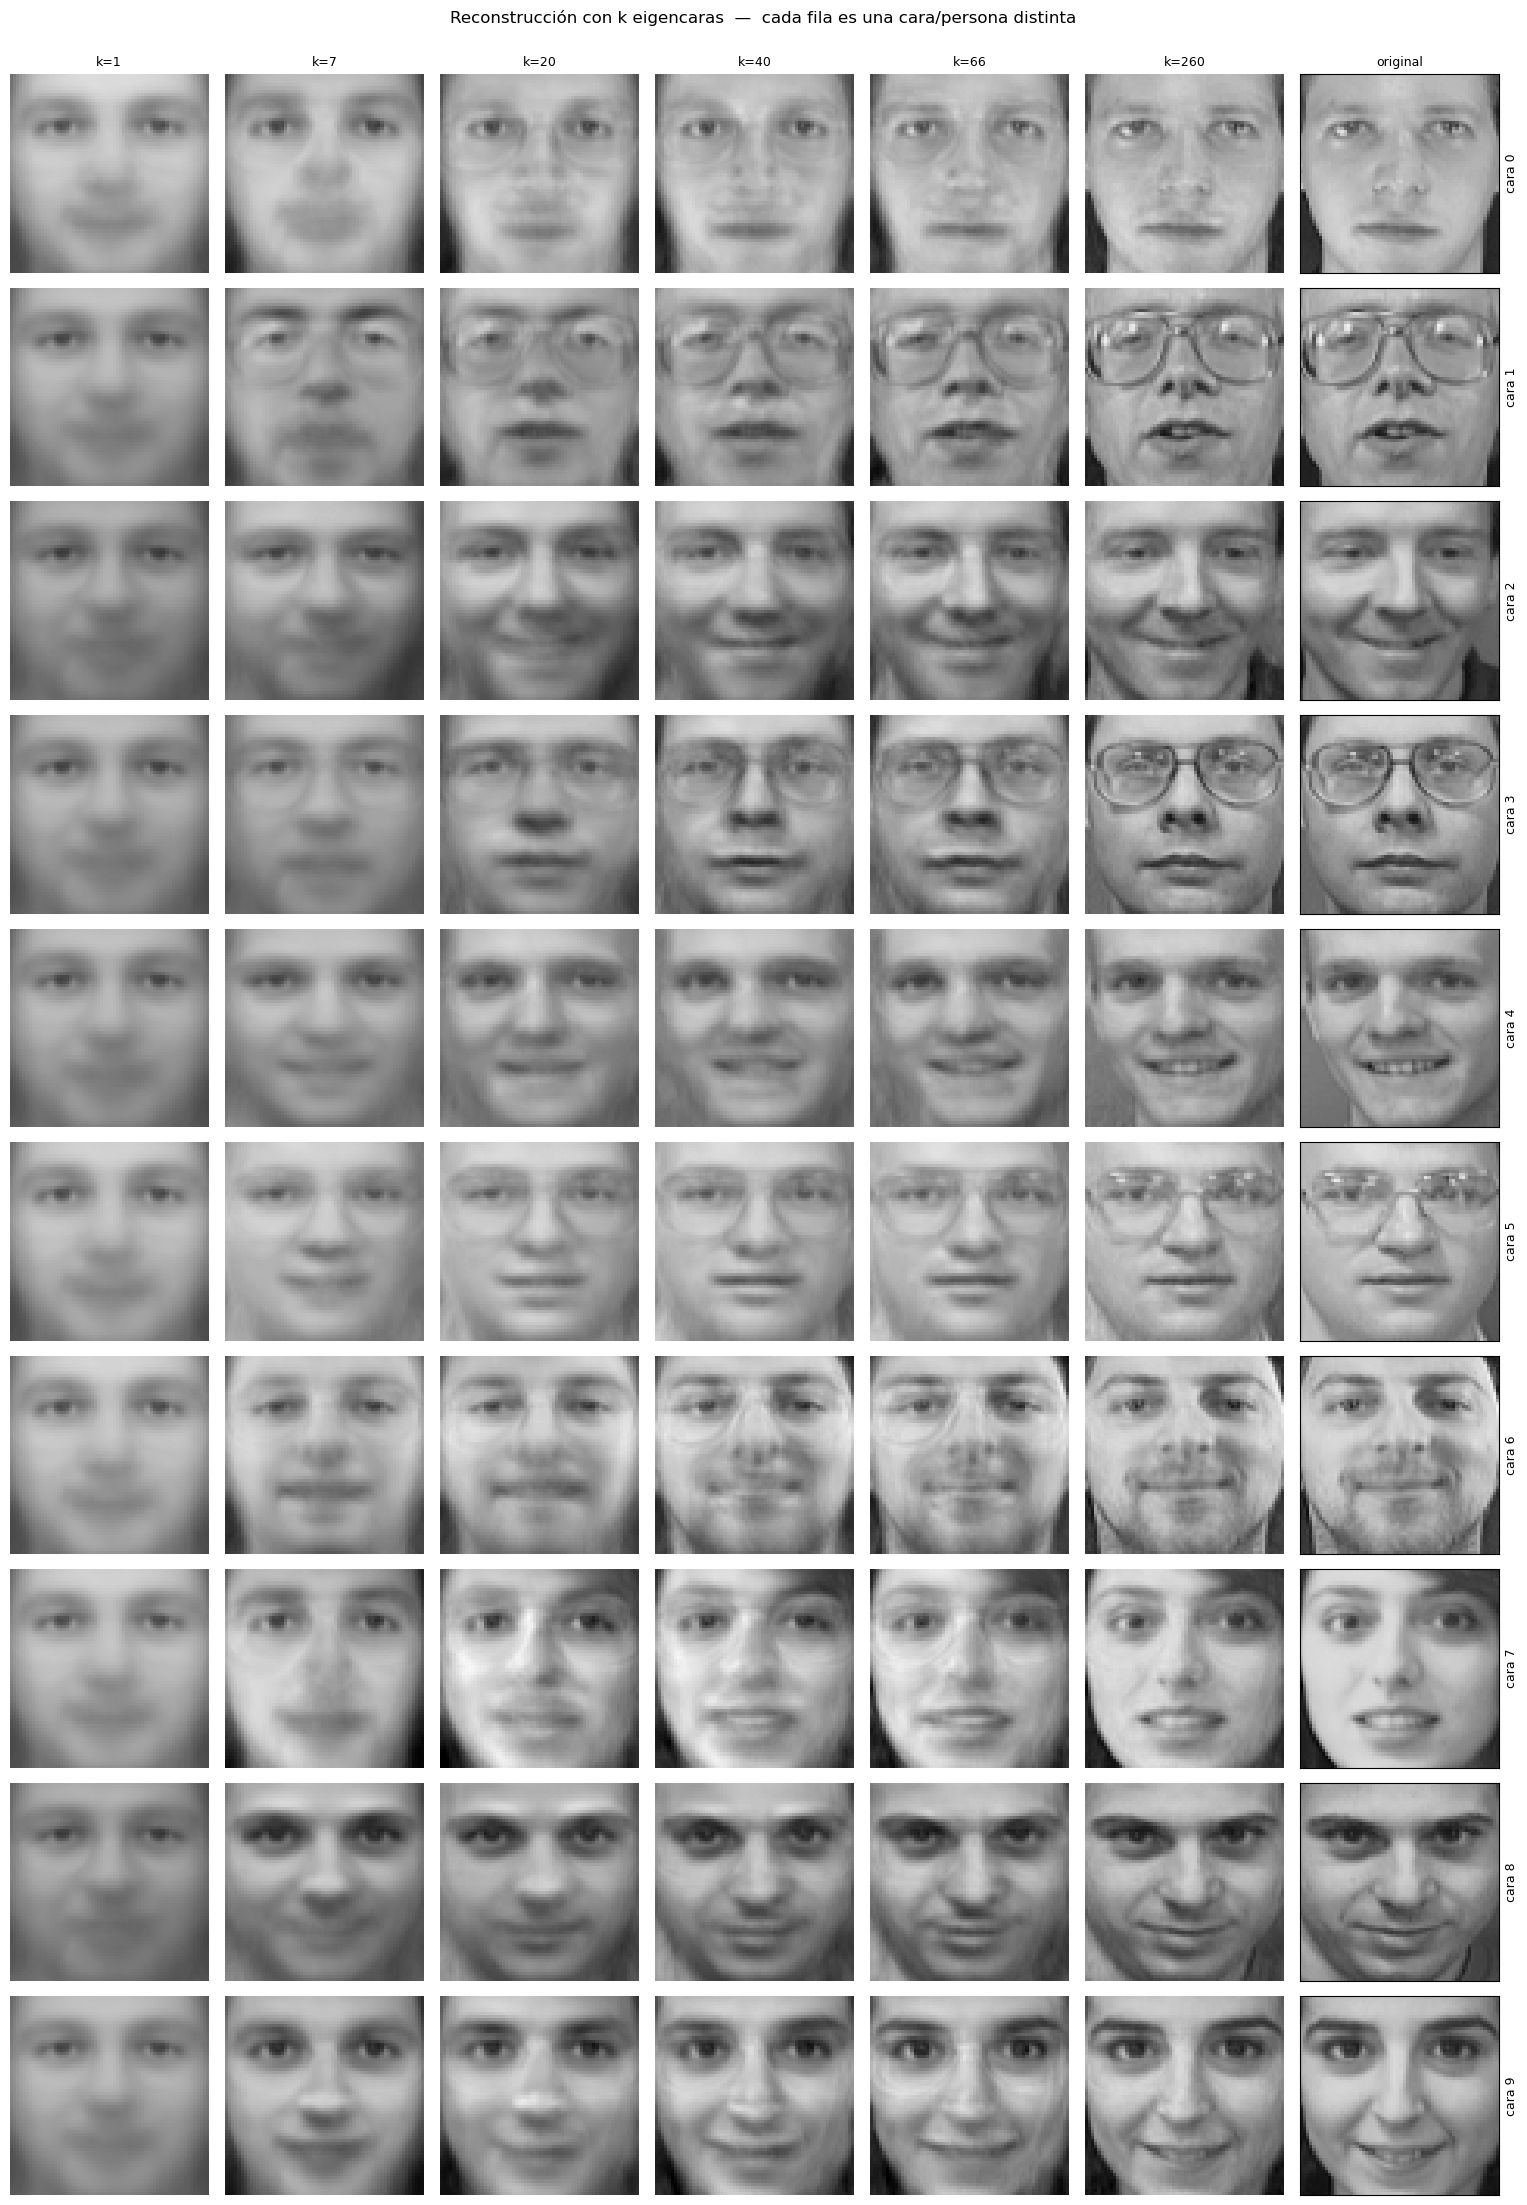

In [9]:
k_values = [1, 7, 20, 40, 66, 260]   # columnas de la grilla

mean_img = X_faces.mean(axis=0)  # imagen promedio (sin centrar)
Z_faces = U @ np.diag(S) # calculamos las proyecciones

# Un ejemplo representativo por clase (0–9)
examples_idx = [np.where(y_faces == d)[0][0] for d in range(10)]
X_ex   = X_faces[examples_idx]     
X_ex_c = centered_x[examples_idx] 
Z_ex   = Z_faces[examples_idx]

n_cols = len(k_values) + 1        # una columna por k + original al final
fig, axes = plt.subplots(10, n_cols, figsize=(2.2 * n_cols, 22))

for row, digit in enumerate(range(10)):
    # Columnas 0..k-1: reconstrucciones
    for col, k in enumerate(k_values):
        recon = Z_ex[row, :k] @ Vt[:k] + mean_img
        recon = np.clip(recon, 0.0, 1.0)
        axes[row, col].imshow(recon.reshape(64, 64), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f"k={k}", fontsize=9)

    # Última columna: imagen original
    axes[row, -1].imshow(X_ex[row].reshape(64, 64), cmap='gray', vmin=0, vmax=1)
    axes[row, -1].set_ylabel(f"cara {digit}", fontsize=9)
    axes[row, -1].yaxis.set_label_position('right')
    axes[row, -1].set_xticks([])
    axes[row, -1].set_yticks([])
    if row == 0:
        axes[row, -1].set_title("original", fontsize=9)

fig.suptitle("Reconstrucción con k eigencaras  —  cada fila es una cara/persona distinta", y=1)
plt.savefig('output-figures/Gráfico_parte_C.png')
plt.tight_layout()
plt.show()